In [ ]:
#Source: https://towardsdatascience.com/a-beginners-guide-to-text-classification-with-scikit-learn-632357e16f3a

In [ ]:
#Question: How to convert single nucletide --> codon --> BOW analysis vs Word2vec vs le-tre-codon?

In [ ]:
#Notes: Stopwords...

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from imblearn.under_sampling import  RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv('IMDB Dataset.csv')

In [3]:
df.dtypes

review       object
sentiment    object
dtype: object

In [4]:
df.shape

(50000, 2)

In [5]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [6]:
df_plus = df[df["sentiment"]=='positive'][:9000]
df_minus = df[df['sentiment']=='negative'][:1000]

In [17]:
df_sample = pd.concat([df_plus, df_minus])

In [18]:
df_sample.count()

review       10000
sentiment    10000
dtype: int64

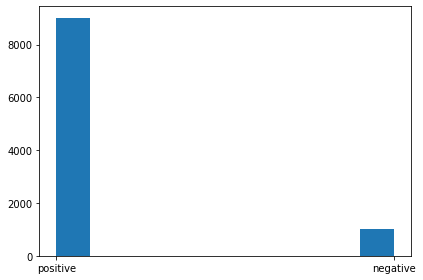

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=1)
plt.hist(df_sample['sentiment'])
fig.tight_layout()

In [20]:
rus = RandomUnderSampler(random_state=0)
df_sample_bal,df_sample_bal['sentiment']=rus.fit_resample(df_sample[['review']],
                                                             df_sample['sentiment'])

df_training_bal.count()

review       2000
sentiment    2000
dtype: int64

In [23]:
train, test = train_test_split(df_sample_bal, test_size=0.33, random_state=42)

In [24]:
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

In [34]:
tfidf = TfidfVectorizer(stop_words='english')
train_x_vector = tfidf.fit_transform(train_x)
train_x_vector

<1340x20625 sparse matrix of type '<class 'numpy.float64'>'
	with 118834 stored elements in Compressed Sparse Row format>

In [35]:
pd.DataFrame.sparse.from_spmatrix(train_x_vector,
                                 index=train_x.index,
                                  columns=tfidf.get_feature_names())

,00,000,007,01pm,02,04,08,10,100,1000,...,zooming,zooms,zues,zzzzzzzzzzzzzzzzzz,æon,élan,émigré,ísnt,ïn,ünfaithful
81,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
915,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
380,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.042791,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1029,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
860,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1459,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
test_x_vector = tfidf.transform(test_x)

In [47]:
#Support Vector Machine Example
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(train_x_vector, train_y)

SVC(kernel='linear')

In [48]:
print(svc.predict(tfidf.transform(['the experince reminded me highschool prom'])))

['negative']


In [52]:
#Decision Tree Example
from sklearn.tree import DecisionTreeClassifier

dec_tree = DecisionTreeClassifier()
dec_tree.fit(train_x_vector, train_y)
print(dec_tree.predict(tfidf.transform(['the experince reminded me highschool prom'])))

['positive']


In [55]:
#Naive Bayes Example
#Error...: https://stackoverflow.com/questions/28384680/scikit-learns-pipeline-a-sparse-matrix-was-passed-but-dense-data-is-required
#Error reasoning: Sparse data has few disitinct values, dense has many distinct values (non-zero...)
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(train_x_vector.toarray(), train_y)
print(gnb.predict(tfidf.transform(['the experince reminded me highschool prom'])))

TypeError: A sparse matrix was passed, but dense data is required. Use X.toarray() to convert to a dense numpy array.

In [56]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(train_x_vector, train_y)
print(log_reg.predict(tfidf.transform(['the experince reminded me highschool prom'])))

['positive']


In [58]:
#Model Evals:
svc.score(test_x_vector, test_y)
#dec_tree.score(test_x_vector, test_y)
#gnb.score(test_x_vector.toarray(), test_y)
#log_reg.score(test_x_vector, test_y)

0.8409090909090909

In [59]:
#F1 Score: weighted average of precision and recall
#f1_score = 2*(recall*precision)/(recall+precision), where worst = 0
from sklearn.metrics import f1_score

f1_score(test_y, svc.predict(test_x_vector),
        labels=['positive', 'negative'],
        average=None)

array([0.84671533, 0.83464567])

In [60]:
#Classification Reports:
from sklearn.metrics import classification_report

print(classification_report(test_y,
                           svc.predict(test_x_vector),
                           labels=['positive', 'negative']))

              precision    recall  f1-score   support

    positive       0.83      0.87      0.85       335
    negative       0.85      0.82      0.83       325

    accuracy                           0.84       660
   macro avg       0.84      0.84      0.84       660
weighted avg       0.84      0.84      0.84       660



In [62]:
#Confusion Matrix:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(test_y,
                           svc.predict(test_x_vector),
                           labels=['positive', 'negative'])
conf_mat

array([[290,  45],
       [ 60, 265]])

In [66]:
#maximization
from sklearn.model_selection import GridSearchCV

parameters = {'C': [1,4,8,16,32], 'kernel':['linear', 'rbf']}
svc = SVC()
svc_grid = GridSearchCV(svc,parameters, cv=5)

svc_grid.fit(train_x_vector, train_y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 4, 8, 16, 32], 'kernel': ['linear', 'rbf']})

In [67]:
print(svc_grid.best_params_)
print(svc_grid.best_estimator_)

{'C': 1, 'kernel': 'linear'}
SVC(C=1, kernel='linear')
